# DQI (Decoded Quantum Interferometry) CVRP Solver

Core DQI loop per route:
1. Express subset selection as a QUBO using Clarke-Wright savings.
2. Build a poly-depth quantum circuit:
   `|0>^q -> H^q -> PhaseOracle(gamma) -> H^q` (× layers)
3. Sample from the circuit (shots measurements).
4. Classical decoding: score every distinct bitstring with the full `subset_score` function, return the best feasible subset.

## Imports

In [1]:
import math
import itertools
from typing import Dict, Tuple, List, Set, Optional

import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector

try:
    from qiskit_aer import Aer
    HAS_AER = True
except Exception:
    HAS_AER = False

## Global Configuration

These variables replace the old `__init__` parameters and are used by all functions below.

In [2]:
# ── Problem parameters (set these before calling anything) ──
customers: Dict[int, Tuple[float, float]] = {}
Nv: int = 0
C: int = 0
depot: Tuple[float, float] = (0.0, 0.0)
q: int = 6            # neighborhood_qubits
shots: int = 2048
gamma: float = 0.8
layers: int = 1
seed: int = 0

# ── Derived state (populated by init_problem) ──
coords: Dict[int, Tuple[float, float]] = {}
customer_ids: List[int] = []
nodes: List[int] = []
n: int = 0
dist: Dict[Tuple[int, int], float] = {}

## Initialization

In [3]:
def init_problem(
    _customers: Dict[int, Tuple[float, float]],
    _Nv: int,
    _C: int,
    _depot: Tuple[float, float] = (0.0, 0.0),
    neighborhood_qubits: int = 6,
    _shots: int = 2048,
    _gamma: float = 0.8,
    _layers: int = 1,
    _seed: int = 0,
):
    """Initialize all global problem state (replaces the old __init__)."""
    global customers, Nv, C, depot, q, shots, gamma, layers, seed
    global coords, customer_ids, nodes, n, dist

    customers = _customers
    Nv = _Nv
    C = _C
    depot = _depot
    q = neighborhood_qubits
    shots = _shots
    gamma = _gamma
    layers = _layers
    seed = _seed

    coords = {0: depot, **customers}
    customer_ids = sorted(customers.keys())
    nodes = [0] + customer_ids
    n = len(customer_ids)

    dist = {
        (i, j): _euclidean(i, j)
        for i in nodes for j in nodes
    }

## Geometry

In [4]:
def _euclidean(i: int, j: int) -> float:
    x1, y1 = coords[i]
    x2, y2 = coords[j]
    return math.hypot(x1 - x2, y1 - y2)

In [5]:
def route_cost(route: List[int]) -> float:
    if not route:
        return 0.0
    total = dist[(0, route[0])]
    for a, b in zip(route[:-1], route[1:]):
        total += dist[(a, b)]
    total += dist[(route[-1], 0)]
    return total

## Exact Ordering — Held-Karp TSP

In [6]:
def best_order_for_subset(subset: List[int]) -> Tuple[List[int], float]:
    subset = list(subset)
    m = len(subset)
    if m == 0:
        return [], 0.0
    if m == 1:
        return subset[:], route_cost(subset)

    idx_to_customer = {i: subset[i] for i in range(m)}
    DP = {}
    parent = {}

    for j in range(m):
        mask = 1 << j
        cj = idx_to_customer[j]
        DP[(mask, j)] = dist[(0, cj)]
        parent[(mask, j)] = None

    for mask in range(1, 1 << m):
        for j in range(m):
            if not (mask & (1 << j)):
                continue
            if (mask, j) not in DP:
                continue
            for nxt in range(m):
                if mask & (1 << nxt):
                    continue
                new_mask = mask | (1 << nxt)
                cj = idx_to_customer[j]
                cn = idx_to_customer[nxt]
                cand = DP[(mask, j)] + dist[(cj, cn)]
                if (new_mask, nxt) not in DP or cand < DP[(new_mask, nxt)]:
                    DP[(new_mask, nxt)] = cand
                    parent[(new_mask, nxt)] = j

    full = (1 << m) - 1
    best_cost = float("inf")
    best_last = None

    for j in range(m):
        cj = idx_to_customer[j]
        cand = DP[(full, j)] + dist[(cj, 0)]
        if cand < best_cost:
            best_cost = cand
            best_last = j

    order_idx = []
    mask = full
    j = best_last
    while j is not None:
        order_idx.append(j)
        prev = parent[(mask, j)]
        mask ^= (1 << j)
        j = prev
    order_idx.reverse()

    order = [idx_to_customer[i] for i in order_idx]
    return order, best_cost

## Local Neighborhood

In [7]:
def nearest_neighbors(seed_node: int, pool: Set[int], k: int) -> List[int]:
    arr = list(pool)
    arr.sort(key=lambda c: dist[(seed_node, c)])
    return arr[:k]

## Scoring (classical decoding)

In [8]:
def subset_score(subset: List[int]) -> float:
    if len(subset) == 0:
        return -1e9
    if len(subset) > C:
        return -1e9

    _, route_c = best_order_for_subset(subset)

    pair_dispersion = sum(
        dist[(i, j)] for i, j in itertools.combinations(subset, 2)
    )
    depot_pull = sum(dist[(0, i)] for i in subset)

    return (
        8.0 * len(subset)
        - 1.0 * route_c
        - 0.07 * pair_dispersion
        - 0.03 * depot_pull
    )

## QUBO Encoding

In [9]:
def _build_qubo_coefficients(
    neighborhood: List[int],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Encode subset scoring as a QUBO: f(x) = sum_i h_i x_i + sum_{i<j} J_ij x_i x_j

    Linear terms h_i:
        8.0 reward for including customer i
        minus depot round-trip cost (approximates individual routing cost)
        plus soft capacity penalty linear part: lambda*(1 - 2*C)

    Quadratic terms J_ij:
        Clarke-Wright savings: dist(0,i) + dist(0,j) - dist(i,j)
        minus pair dispersion penalty
        minus soft capacity penalty quadratic part: 2*lambda
    """
    q_len = len(neighborhood)
    h = np.zeros(q_len)
    J = np.zeros((q_len, q_len))
    lam = 5.0

    for i, ci in enumerate(neighborhood):
        h[i] = 8.0 - dist[(0, ci)]
        h[i] += lam * (1.0 - 2.0 * C)

    for i in range(q_len):
        for j in range(i + 1, q_len):
            ci, cj = neighborhood[i], neighborhood[j]
            savings = (
                dist[(0, ci)] + dist[(0, cj)] - dist[(ci, cj)]
            )
            J[i, j] = savings - 0.07 * dist[(ci, cj)] - 2.0 * lam

    return h, J

In [10]:
def _qubo_to_ising(
    h: np.ndarray,
    J: np.ndarray,
) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Convert QUBO (x_i in {0,1}) to Ising (z_i in {-1,+1}).
    Substitution: x_i = (1 - z_i) / 2
    """
    q_len = len(h)
    offset = 0.0
    h_z = np.zeros(q_len)
    J_z = np.zeros((q_len, q_len))

    for i in range(q_len):
        offset += h[i] / 2.0
        h_z[i] -= h[i] / 2.0

    for i in range(q_len):
        for j in range(i + 1, q_len):
            if abs(J[i, j]) < 1e-15:
                continue
            offset += J[i, j] / 4.0
            h_z[i] -= J[i, j] / 4.0
            h_z[j] -= J[i, j] / 4.0
            J_z[i, j] += J[i, j] / 4.0

    return offset, h_z, J_z

## DQI Circuit — Poly-depth, No Classical 2^q Enumeration

In [11]:
def _build_dqi_circuit(neighborhood: List[int]) -> QuantumCircuit:
    """
    Build the DQI circuit for the given neighborhood.

    Structure (one layer):
        |0>^q -> H^q -> PhaseOracle(gamma) -> H^q -> Measure

    Phase oracle implements e^{i*gamma*(sum h_z_i Z_i + sum J_z_ij Z_i Z_j)}:
        Single-qubit terms: Rz(-2*phi)
        Two-qubit terms:    CNOT(i,j) . Rz(-2*phi, j) . CNOT(i,j)

    Total circuit depth: O(q^2) for dense QUBO.
    """
    q_len = len(neighborhood)
    h_q, J_q = _build_qubo_coefficients(neighborhood)
    _, h_z, J_z = _qubo_to_ising(h_q, J_q)

    # Normalize Ising coefficients to [-1, 1]
    scale = max(np.max(np.abs(h_z)), np.max(np.abs(J_z)), 1e-12)
    h_z /= scale
    J_z /= scale

    qc = QuantumCircuit(q_len, q_len)
    qc.h(range(q_len))  # uniform superposition

    for _ in range(layers):
        # Phase oracle
        for i in range(q_len):
            if abs(h_z[i]) > 1e-12:
                qc.rz(-2.0 * gamma * h_z[i], i)

        for i in range(q_len):
            for j in range(i + 1, q_len):
                if abs(J_z[i, j]) < 1e-12:
                    continue
                qc.cx(i, j)
                qc.rz(-2.0 * gamma * J_z[i, j], j)
                qc.cx(i, j)

        # Interference / mixing
        qc.h(range(q_len))

    qc.measure(range(q_len), range(q_len))
    return qc

## Circuit Execution

In [12]:
def _run_circuit(qc: QuantumCircuit) -> dict:
    if HAS_AER:
        backend = Aer.get_backend("aer_simulator")
        tqc = transpile(qc, backend, seed_transpiler=seed)
        result = backend.run(
            tqc, shots=shots, seed_simulator=seed
        ).result()
        return result.get_counts()

    # Fallback: exact statevector simulation
    qc_copy = qc.copy()
    qc_copy.remove_final_measurements(inplace=True)
    sv = Statevector.from_instruction(qc_copy)
    probs = sv.probabilities_dict()
    return {
        k: int(round(v * shots))
        for k, v in probs.items()
        if v > 1e-12
    }

## Quantum Sampling + Classical Decoding

In [13]:
def _decode(
    candidate: List[int],
    must_include: Optional[int],
) -> List[int]:
    """
    Classical decoding: repair constraint violations in a measured bitstring.
    1. Enforce must_include
    2. Enforce capacity (|subset| <= C)
    """
    candidate = list(candidate)

    if must_include is not None and must_include not in candidate:
        candidate = [must_include] + candidate

    if len(candidate) > C:
        if must_include is not None:
            optional = [c for c in candidate if c != must_include]
            optional.sort(key=lambda c: dist[(must_include, c)])
            candidate = [must_include] + optional[: C - 1]
        else:
            candidate = candidate[: C]

    return candidate

In [14]:
def quantum_sample_subset(
    neighborhood: List[int],
    must_include: Optional[int] = None,
) -> List[int]:
    """
    Run the DQI circuit and apply classical decoding.
    Evaluate every distinct measured bitstring using the full
    subset_score function and return the best feasible subset.
    """
    qc = _build_dqi_circuit(neighborhood)
    counts = _run_circuit(qc)

    if not counts:
        return [must_include] if must_include is not None else []

    best_subset: Optional[List[int]] = None
    best_score = -float("inf")

    for bitstring in counts:
        bits = bitstring[::-1]
        raw = [neighborhood[idx] for idx, bit in enumerate(bits) if bit == "1"]

        decoded = _decode(raw, must_include)

        score = subset_score(decoded)
        if score > best_score:
            best_score = score
            best_subset = decoded

    return best_subset if best_subset else (
        [must_include] if must_include is not None else []
    )

## Build Full CVRP Solution

In [15]:
def build_solution() -> List[List[int]]:
    remaining = set(customer_ids)
    routes = []

    while remaining:
        seed_node = max(remaining, key=lambda c: dist[(0, c)])

        neighborhood = [seed_node] + nearest_neighbors(
            seed_node, remaining - {seed_node}, q - 1
        )
        neighborhood = list(dict.fromkeys(neighborhood))

        subset = quantum_sample_subset(
            neighborhood=neighborhood,
            must_include=seed_node,
        )
        subset = [c for c in subset if c in remaining]

        if len(subset) < min(C, len(remaining)):
            missing = min(C, len(remaining)) - len(subset)
            candidates = [
                c for c in neighborhood if c in remaining and c not in subset
            ]
            candidates.sort(key=lambda c: dist[(seed_node, c)])
            subset += candidates[:missing]

        order, _ = best_order_for_subset(subset)
        routes.append(order)
        for c in order:
            remaining.remove(c)

    return routes

## Classical Cleanup

In [16]:
def two_opt(route: List[int]) -> List[int]:
    best = route[:]
    improved = True
    while improved:
        improved = False
        base = route_cost(best)
        n_r = len(best)
        for i in range(n_r - 1):
            for j in range(i + 1, n_r):
                cand = best[:i] + best[i:j+1][::-1] + best[j+1:]
                c = route_cost(cand)
                if c + 1e-9 < base:
                    best = cand
                    base = c
                    improved = True
    return best

In [17]:
def improve_routes(routes: List[List[int]], passes: int = 10) -> List[List[int]]:
    routes = [two_opt(r) for r in routes]

    for _ in range(passes):
        changed = False
        for a in range(len(routes)):
            for b in range(a + 1, len(routes)):
                ra, rb = routes[a], routes[b]
                base = route_cost(ra) + route_cost(rb)
                best_pair = None
                best_delta = 0.0

                for ia, ca in enumerate(ra):
                    for ib, cb in enumerate(rb):
                        na = ra[:]
                        nb = rb[:]
                        na[ia], nb[ib] = cb, ca
                        na, cna = best_order_for_subset(na)
                        nb, cnb = best_order_for_subset(nb)
                        new_cost = cna + cnb
                        delta = base - new_cost
                        if delta > best_delta + 1e-9:
                            best_delta = delta
                            best_pair = (na, nb)

                if best_pair is not None:
                    routes[a], routes[b] = best_pair
                    changed = True

        routes = [two_opt(r) for r in routes]
        if not changed:
            break

    return routes

## Solve

In [18]:
def solve(do_classical_cleanup: bool = True, verbose: bool = True):
    routes = build_solution()
    init_cost = sum(route_cost(r) for r in routes)

    if do_classical_cleanup:
        routes = improve_routes(routes)

    final_cost = sum(route_cost(r) for r in routes)

    if verbose:
        print("DQI (Decoded Quantum Interferometry) CVRP solution")
        print(f"Neighborhood qubits per DQI call: {q}")
        print(f"DQI layers: {layers}  gamma: {gamma}")
        print(f"Shots per quantum call: {shots}")
        print()
        for k, r in enumerate(routes, start=1):
            print(
                f"Vehicle {k}: [0, " + ", ".join(map(str, r)) + ", 0] "
                f"load={len(r)} cost={route_cost(r):.4f}"
            )
        print(f"\nInitial total cost: {init_cost:.4f}")
        print(f"Final total cost:   {final_cost:.4f}")

    return routes, final_cost

## Convergence Analysis

## Convergence Analysis — Cumulative Energy vs Total Circuit Evaluations

Track every bitstring evaluation inside the DQI solve process and plot
the running best solution cost (as negative energy) against cumulative
circuit evaluations.

In [22]:
import matplotlib.pyplot as plt
import csv, time, os
import numpy as np

def bitstring_to_z(bitstring: str) -> np.ndarray:
    """
    Convert measured bitstring to Ising spins z in {-1, +1}.
    Keeps the same bit ordering convention used elsewhere in the notebook.
    """
    bits = bitstring[::-1]
    return np.array([1.0 if b == "0" else -1.0 for b in bits], dtype=float)

def encoded_energy(bitstring: str, neighborhood, normalized=False) -> float:
    """
    Compute the circuit-encoded Ising energy for one measured bitstring.

    normalized=False:
        uses the raw Ising coefficients from _qubo_to_ising()

    normalized=True:
        uses the normalized coefficients actually used in _build_dqi_circuit()
    """
    h_q, J_q = _build_qubo_coefficients(neighborhood)
    offset, h_z, J_z = _qubo_to_ising(h_q, J_q)

    if normalized:
        scale = max(np.max(np.abs(h_z)), np.max(np.abs(J_z)), 1e-12)
        h_z = h_z / scale
        J_z = J_z / scale
        offset = offset / scale

    z = bitstring_to_z(bitstring)

    e = offset + np.dot(h_z, z)
    q_len = len(z)
    for i in range(q_len):
        for j in range(i + 1, q_len):
            e += J_z[i, j] * z[i] * z[j]

    return float(e)

# ── Convergence-tracked build_solution using encoded Ising energy ──
def build_solution_tracked(normalized_energy=False):
    """
    Same as build_solution() but records convergence data using
    the circuit's encoded Ising energy instead of -route_cost.

    Each unique measured bitstring counts as one circuit evaluation.
    log entries are (cum_evals, cumulative_energy).
    """
    remaining = set(customer_ids)
    routes = []
    cum_evals = 0
    log = []

    # Track the accumulated baseline energy of previously optimized routes
    settled_energy = 0.0

    while remaining:
        seed_node = max(remaining, key=lambda c: dist[(0, c)])
        neighborhood = [seed_node] + nearest_neighbors(
            seed_node, remaining - {seed_node}, q - 1
        )
        neighborhood = list(dict.fromkeys(neighborhood))

        # ── Run DQI circuit ──
        qc = _build_dqi_circuit(neighborhood)
        counts = _run_circuit(qc)

        best_subset = None
        best_score = -float("inf")
        
        # Reset local minimum for the current vehicle route
        curr_min = float("inf")

        if counts:
            for bitstring in counts:
                cum_evals += 1

                # encoded circuit energy for this measured bitstring
                e = encoded_energy(
                    bitstring, neighborhood, normalized=normalized_energy
                )
                
                # Update running minimum for this specific local route
                curr_min = min(curr_min, e)

                bits = bitstring[::-1]
                raw = [neighborhood[idx] for idx, bit in enumerate(bits)
                       if bit == "1"]
                decoded = _decode(raw, seed_node)
                score = subset_score(decoded)

                if score > best_score:
                    best_score = score
                    best_subset = decoded

                # snapshot: accumulated previous routes + current running minimum
                log.append((cum_evals, settled_energy + curr_min))

        subset = best_subset if best_subset else [seed_node]
        subset = [c for c in subset if c in remaining]

        if len(subset) < min(C, len(remaining)):
            missing = min(C, len(remaining)) - len(subset)
            candidates = [
                c for c in neighborhood
                if c in remaining and c not in subset
            ]
            candidates.sort(key=lambda c: dist[(seed_node, c)])
            subset += candidates[:missing]

        order, _ = best_order_for_subset(subset)
        routes.append(order)

        for c in order:
            remaining.remove(c)

        # Lock in the best local energy for this route into the accumulator
        if curr_min != float("inf"):
            settled_energy += curr_min

        # optional extra point after route finalization
        if log:
            log.append((cum_evals, settled_energy))

    return routes, log

def solve_tracked(do_classical_cleanup=True, verbose=True, normalized_energy=False):
    """
    Solve with convergence tracking based on encoded Ising energy.
    """
    routes, log = build_solution_tracked(
        normalized_energy=normalized_energy
    )
    init_cost = sum(route_cost(r) for r in routes)

    if do_classical_cleanup:
        routes = improve_routes(routes)

    final_cost = sum(route_cost(r) for r in routes)

    if verbose:
        print(f"  Init cost: {init_cost:.4f} → Final cost: {final_cost:.4f}")

    return routes, final_cost, log

In [23]:
# ── Instance definitions ──
instances = {
    "Instance 1": {
        "Nv": 2, "C": 5, "depot": (0, 0),
        "customers": {1: (-2, 2), 2: (-5, 8), 3: (2, 3)},
    },
    "Instance 2": {
        "Nv": 2, "C": 2, "depot": (0, 0),
        "customers": {1: (-2, 2), 2: (-5, 8), 3: (2, 3)},
    },
    "Instance 3": {
        "Nv": 3, "C": 2, "depot": (0, 0),
        "customers": {
            1: (-2, 2), 2: (-5, 8), 3: (2, 3),
            4: (5, 7), 5: (2, 4), 6: (2, -3),
        },
    },
    "Instance 4": {
        "Nv": 4, "C": 3, "depot": (0, 0),
        "customers": {
            1: (-2, 2), 2: (-5, 8), 3: (6, 3), 4: (4, 4),
            5: (3, 2), 6: (0, 2), 7: (-2, 3), 8: (-4, 3),
            9: (2, 3), 10: (2, 7), 11: (-2, 5), 12: (-1, 4),
        },
    },
    "Instance 5": {
        "Nv": 5, "C": 4, "depot": (0, 0),
        "customers": {
            1: (-2, 2), 2: (-5, 8), 3: (2, 3), 4: (5, 7),
            5: (2, 4), 6: (2, -3), 7: (-4, 1), 8: (0, 6),
            9: (3, -2), 10: (-1, 5), 11: (6, 1), 12: (-3, 4),
            13: (4, 3), 14: (-6, 2), 15: (1, 7), 16: (5, -1),
            17: (-2, -4), 18: (3, 6), 19: (-5, 5), 20: (0, -2),
        },
    },
    "Instance 6": {
        "Nv": 5, "C": 5, "depot": (0, 0),
        "customers": {
            1: (-3, 4), 2: (-6, 7), 3: (2, 3), 4: (5, 8),
            5: (3, 5), 6: (1, -4), 7: (-5, 1), 8: (0, 7),
            9: (4, -2), 10: (-1, 6), 11: (6, 2), 12: (-4, 3),
            13: (7, 5), 14: (-7, 2), 15: (1, 9), 16: (5, -1),
            17: (-2, -5), 18: (3, 7), 19: (-6, 5), 20: (0, -3),
            21: (8, 1), 22: (-2, 8), 23: (4, 0), 24: (-5, -2),
            25: (2, 6),
        },
    },
}

SEEDS = [0, 42, 123, 256, 999]

# ── Run all instances, collect convergence logs ──
all_convergence = {}  # inst_name -> list of (evals, energy) across best seed

for inst_name, inst_data in instances.items():
    print(f"\n{'='*60}")
    print(f"  {inst_name}: Nv={inst_data['Nv']}, C={inst_data['C']}, "
          f"n={len(inst_data['customers'])}")
    print(f"{'='*60}")

    best_cost = float("inf")
    best_log = []

    for trial_seed in SEEDS:
        init_problem(
            _customers=inst_data["customers"],
            _Nv=inst_data["Nv"],
            _C=inst_data["C"],
            _depot=inst_data["depot"],
            neighborhood_qubits=min(7, len(inst_data["customers"])),
            _shots=2048,
            _gamma=0.8,
            _layers=1,
            _seed=trial_seed,
        )

        routes, cost, log = solve_tracked(
            do_classical_cleanup=True, verbose=False
        )

        print(f"    seed={trial_seed:>3d}  cost={cost:.4f}  "
              f"evals={log[-1][0] if log else 0}")

        if cost < best_cost:
            best_cost = cost
            best_log = log

    all_convergence[inst_name] = best_log
    print(f"  ▸ Best cost: {best_cost:.4f}")

    


  Instance 1: Nv=2, C=5, n=3
    seed=  0  cost=21.7445  evals=8
    seed= 42  cost=21.7445  evals=8
    seed=123  cost=21.7445  evals=8
    seed=256  cost=21.7445  evals=8
    seed=999  cost=21.7445  evals=8
  ▸ Best cost: 21.7445

  Instance 2: Nv=2, C=2, n=3
    seed=  0  cost=26.1817  evals=10
    seed= 42  cost=26.1817  evals=10
    seed=123  cost=26.1817  evals=10
    seed=256  cost=26.1817  evals=10
    seed=999  cost=26.1817  evals=10
  ▸ Best cost: 26.1817

  Instance 3: Nv=3, C=2, n=6
    seed=  0  cost=49.4988  evals=84
    seed= 42  cost=49.4988  evals=84
    seed=123  cost=49.4988  evals=84
    seed=256  cost=49.4988  evals=84
    seed=999  cost=49.4988  evals=84
  ▸ Best cost: 49.4988

  Instance 4: Nv=4, C=3, n=12
    seed=  0  cost=58.4234  evals=328
    seed= 42  cost=58.4234  evals=328
    seed=123  cost=58.4234  evals=328
    seed=256  cost=58.4234  evals=328
    seed=999  cost=58.4234  evals=328
  ▸ Best cost: 58.4234

  Instance 5: Nv=5, C=4, n=20
    seed=  0  co

Saved CSV: dqi_convergence/csv/convergence_1.csv


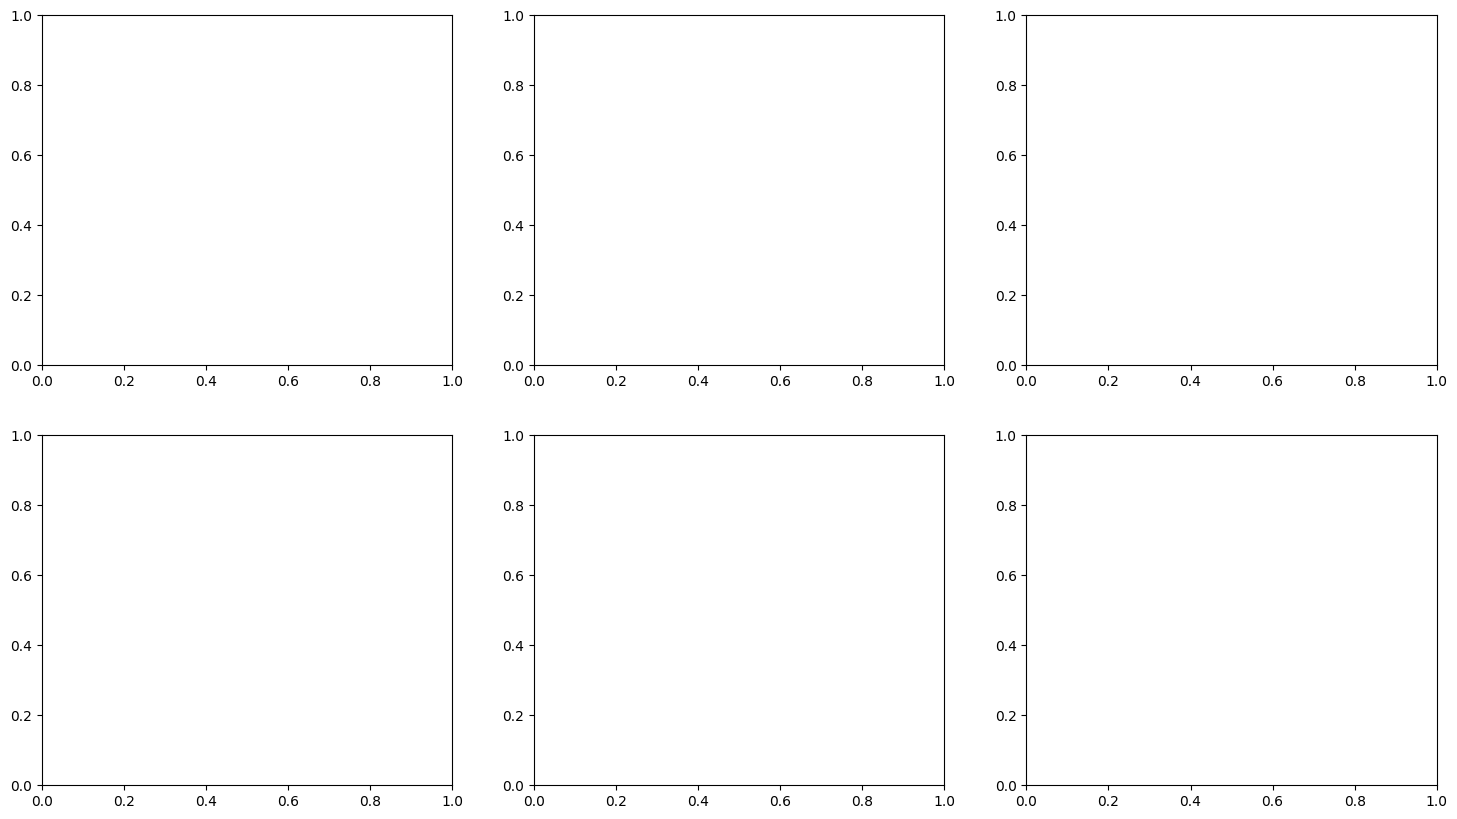

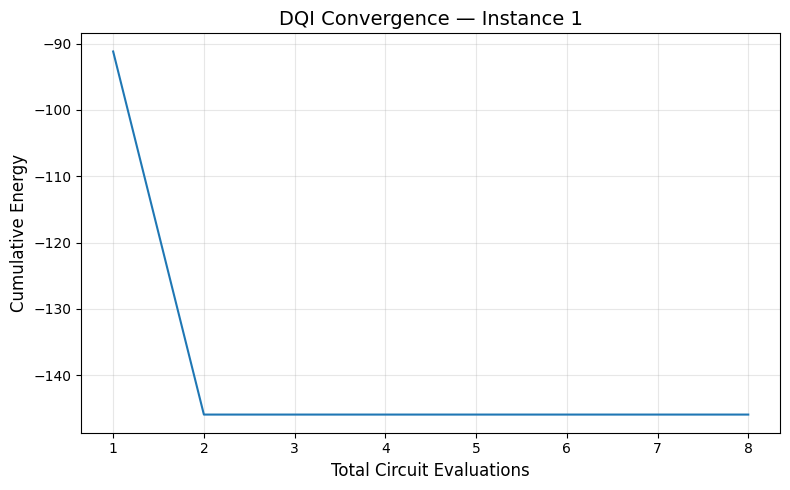

Saved CSV: dqi_convergence/csv/convergence_2.csv


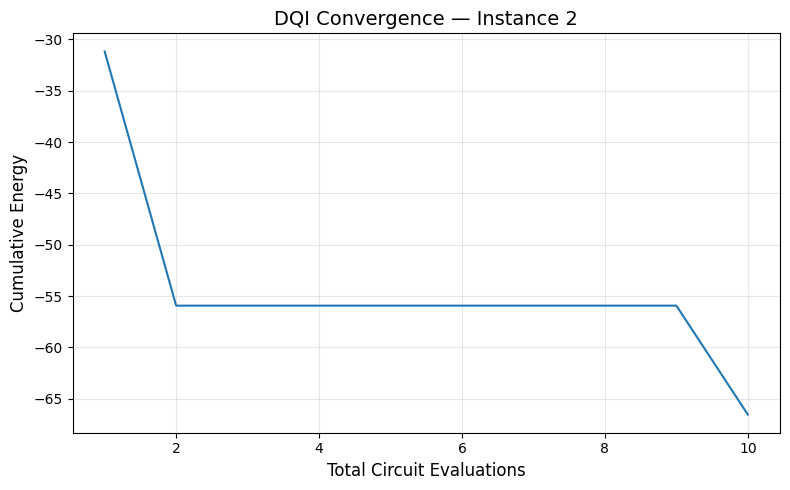

Saved CSV: dqi_convergence/csv/convergence_3.csv


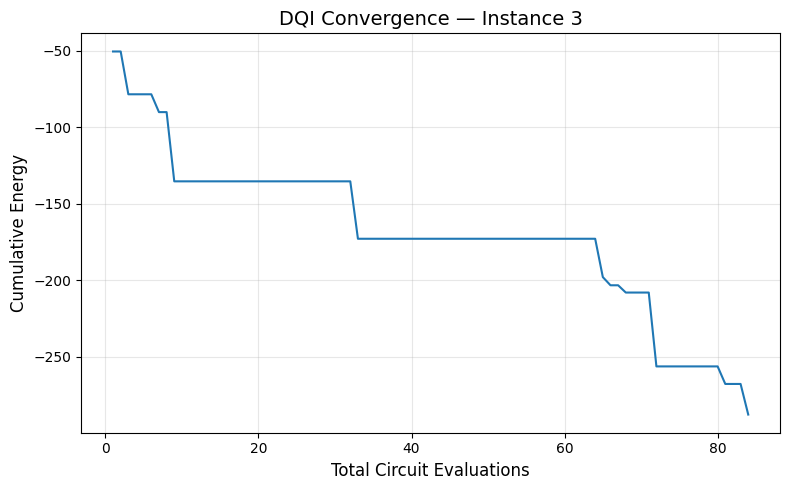

Saved CSV: dqi_convergence/csv/convergence_4.csv


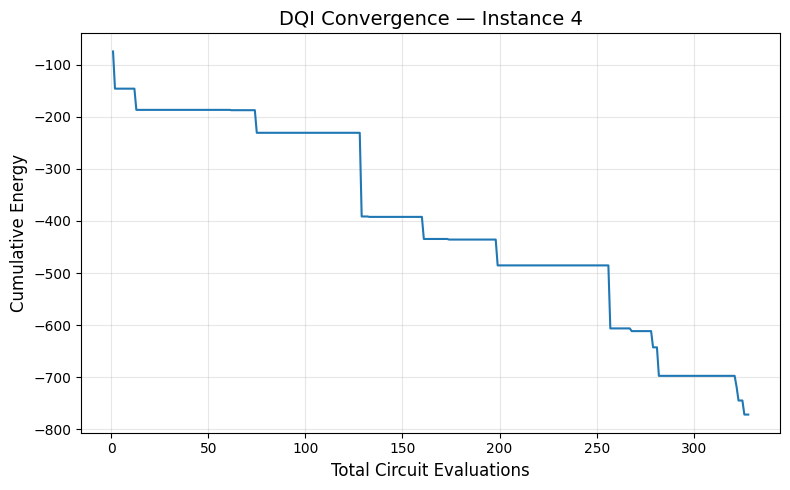

Saved CSV: dqi_convergence/csv/convergence_5.csv


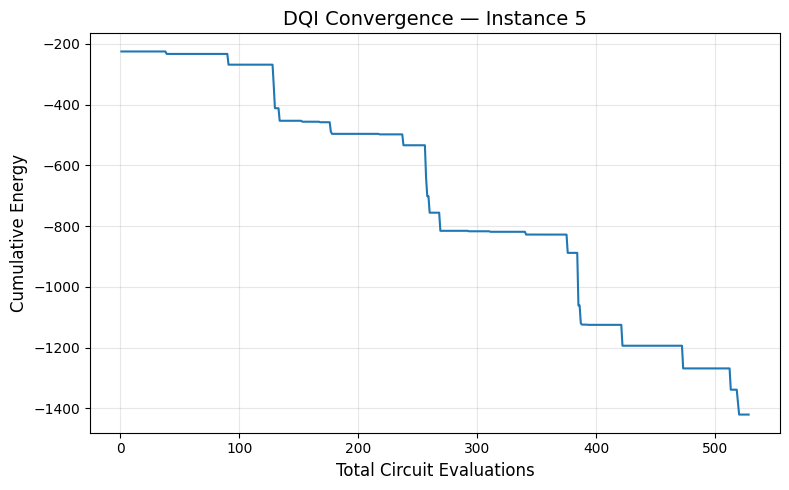

Saved CSV: dqi_convergence/csv/convergence_6.csv


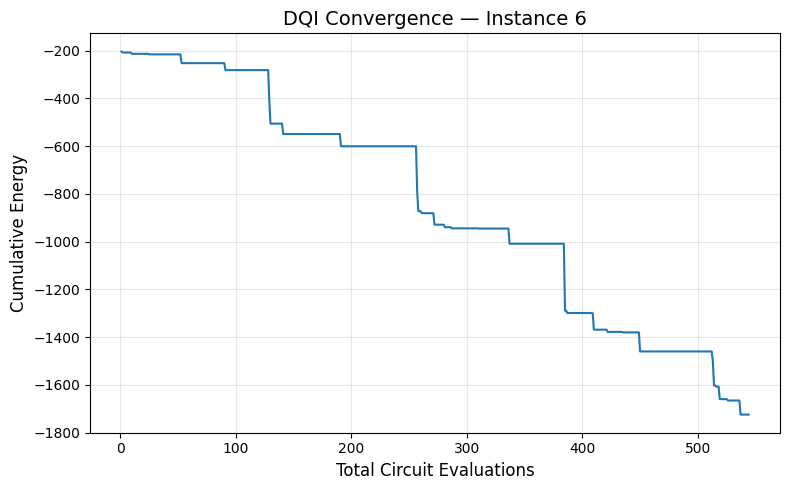

Saved combined plot: dqi_convergence/plots/all_instances_convergence.png


In [25]:
# ── Plot convergence for each instance using encoded Ising energy ──
import os
import csv
import matplotlib.pyplot as plt

# Create directory structure like QAOA
base_dir = "dqi_convergence"
csv_dir = os.path.join(base_dir, "csv")
plots_dir = os.path.join(base_dir, "plots")

os.makedirs(csv_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

fig_all, axes_all = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes_all.flatten()

for idx, (inst_name, log) in enumerate(all_convergence.items()):
    if not log:
        continue

    evals = [pt[0] for pt in log]
    energy = [pt[1] for pt in log]
    
    # Format instance name for saving (e.g., "Instance 1" -> "instance_1")
    safe_name = inst_name.lower().replace(" ", "_")

    # ── 1. Save data to CSV ──
    csv_filename = os.path.join(csv_dir, f"convergence_{safe_name[-1]}.csv")
    with open(csv_filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['circuit_evaluation', 'energy'])
        for x, y in zip(evals, energy):
            writer.writerow([x, round(y, 4)])
    print(f"Saved CSV: {csv_filename}")

    # ── 2. Individual plot ──
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(evals, energy, linewidth=1.5, color="#1f77b4")
    ax.set_xlabel("Total Circuit Evaluations", fontsize=12)
    ax.set_ylabel("Cumulative Energy", fontsize=12)
    ax.set_title(f"DQI Convergence — {inst_name}", fontsize=14)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    plot_filename = os.path.join(plots_dir, f"{safe_name}_convergence.png")
    fig.savefig(plot_filename, dpi=150, bbox_inches="tight")
    plt.show()

    # ── 3. Subplot in combined figure ──
    ax2 = axes_flat[idx]
    ax2.plot(evals, energy, linewidth=1.5, color="#1f77b4")
    ax2.set_xlabel("Total Circuit Evaluations", fontsize=9)
    ax2.set_ylabel("Cumulative Energy", fontsize=9)
    ax2.set_title(f"DQI Convergence — {inst_name}", fontsize=11)
    ax2.grid(True, alpha=0.3)

# Hide unused subplot axes if fewer than 6 instances
for j in range(len(all_convergence), len(axes_flat)):
    axes_flat[j].axis("off")

fig_all.tight_layout()
combined_plot_filename = os.path.join(plots_dir, "all_instances_convergence.png")
fig_all.savefig(combined_plot_filename, dpi=150, bbox_inches="tight")
print(f"Saved combined plot: {combined_plot_filename}")
plt.show()
